# 01 - Visualising the three networks

In [66]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

MAPPING_NAMES = {
    "ring": "Anell Regular",
    "er": "Erdos-Reny",
    "ws": "Watts–Strogatz"
}
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from src.smallworld.networks import build_all
from src.smallworld.plotting import draw_networks_grid, to_pyvis, save_pyvis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1. Build the three networks

In [67]:
N, k, beta = 20, 4, 0.1
graphs = build_all(N=N, k=k, beta=beta)

for name, G in graphs.items():
    avg_deg = 2 * G.number_of_edges() / G.number_of_nodes()
    print(f"{name:>4}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, <deg>={avg_deg:.2f}")

ring: nodes=20, edges=40, <deg>=4.00
  er: nodes=20, edges=32, <deg>=3.20
  ws: nodes=20, edges=40, <deg>=4.00


2. Static comparison

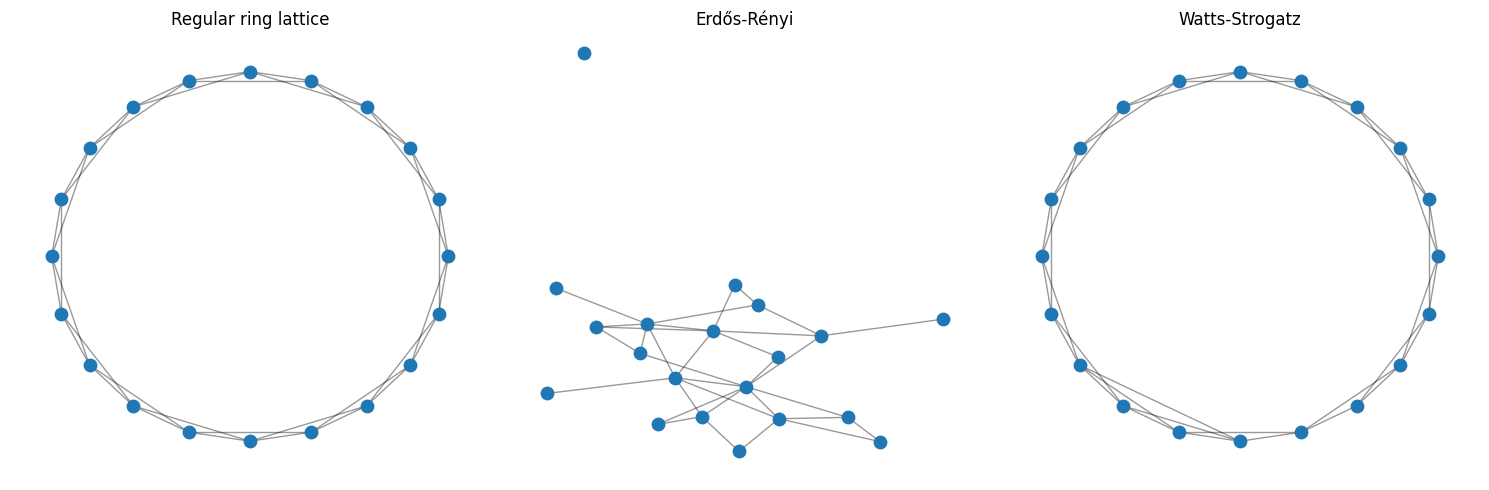

In [68]:
fig = draw_networks_grid(graphs, save=FIGURES / "01_three_networks.png")
plt.show()

3. Interactive visualisations

In [69]:
layouts = {"ring": "circular", "er": "spring", "ws": "circular"}

for name, G in graphs.items():
    net = to_pyvis(G, layout=layouts[name], physics=True)
    out = save_pyvis(net, FIGURES / f"01_{name}.html")
    print(f"saved {out.relative_to(ROOT)}")

saved figures\01_ring.html
saved figures\01_er.html
saved figures\01_ws.html


4.  Simulation

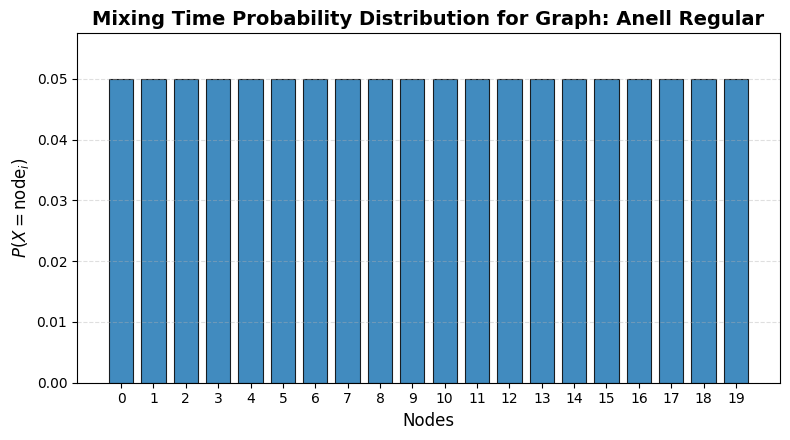

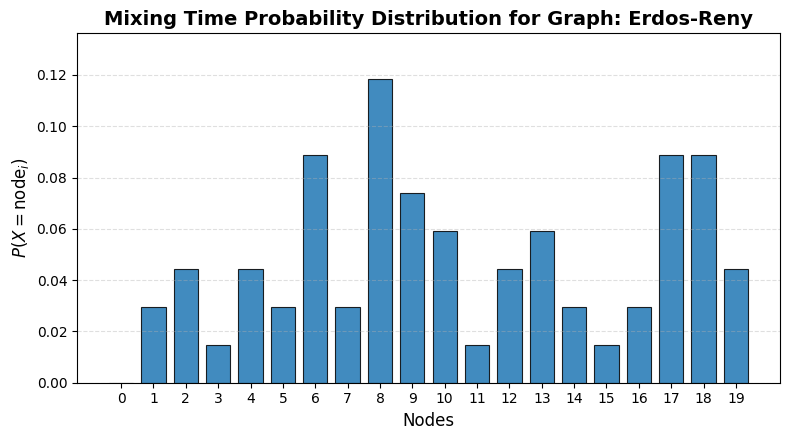

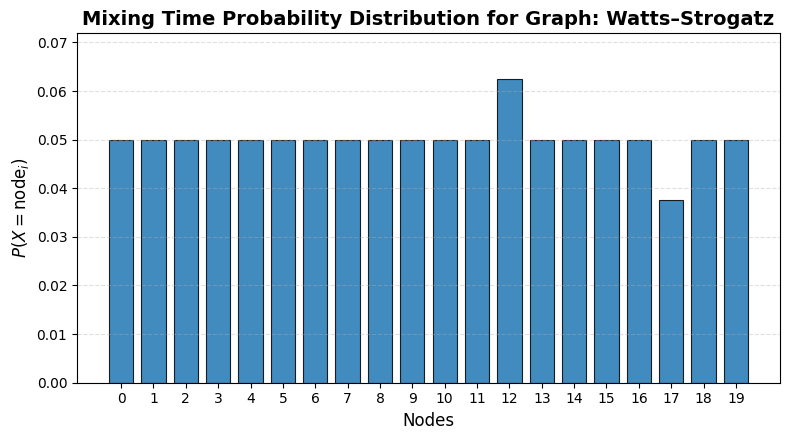

In [70]:
from src.smallworld.simulation import mixing_time, plot_mixing_time_distribution

# ====== Mixing Time ======
n_sims = 50
for name, graph in graphs.items():
    out_dic, _ = mixing_time(G=graph, n_simulations=n_sims)
    all_probs = [dic["distribution"] for dic in out_dic.values()]
    plot_mixing_time_distribution(all_probs, name_graph=MAPPING_NAMES[name])

[148, 108, 45, 83, 54, 96, 145, 87, 80, 171, 157, 108, 155, 149, 107, 126, 47, 72, 229, 185, 94, 54, 72, 58, 88, 56, 80, 78, 56, 254, 99, 101, 111, 109, 80, 51, 203, 156, 75, 58, 81, 132, 92, 111, 143, 112, 167, 199, 175, 90, 106, 83, 52, 151, 121, 81, 46, 110, 165, 66, 80, 92, 93, 103, 82, 74, 218, 146, 113, 176, 84, 70, 128, 60, 54, 176, 77, 65, 53, 101, 109, 74, 269, 98, 246, 68, 91, 133, 91, 118, 53, 56, 227, 167, 111, 69, 95, 96, 88, 88, 53, 94, 95, 131, 66, 80, 80, 92, 144, 55, 111, 74, 93, 202, 150, 109, 240, 79, 50, 153, 217, 175, 204, 86, 198, 81, 135, 81, 139, 98, 67, 160, 250, 71, 179, 117, 76, 72, 103, 65, 101, 132, 94, 164, 94, 159, 60, 76, 144, 61, 91, 82, 80, 115, 189, 111, 102, 128, 236, 103, 141, 99, 84, 211, 113, 82, 74, 45, 100, 100, 82, 80, 99, 151, 78, 99, 71, 98, 56, 97, 104, 103, 70, 93, 43, 104, 168, 59, 155, 164, 103, 103, 59, 71, 182, 98, 66, 184, 85, 127, 117, 174, 119, 49, 117, 84, 79, 76, 41, 99, 165, 116, 105, 91, 55, 258, 195, 65, 278, 83, 146, 77, 70, 15

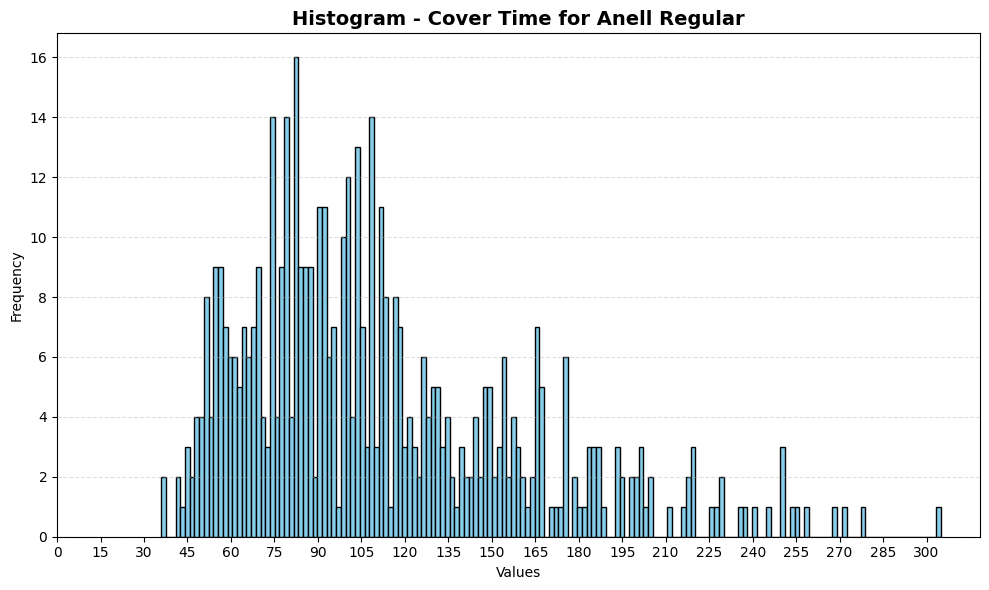

There are few nodes unconnected:
[0]

Calculating cover time without isolated nodes...
[126, 203, 92, 95, 165, 234, 254, 290, 352, 174, 252, 101, 119, 112, 140, 91, 101, 79, 85, 158, 107, 99, 268, 220, 231, 202, 111, 143, 101, 52, 115, 197, 127, 147, 347, 307, 128, 391, 119, 111, 153, 144, 184, 181, 206, 136, 324, 182, 97, 97, 277, 221, 248, 134, 96, 73, 271, 160, 112, 218, 134, 152, 129, 87, 164, 129, 121, 170, 88, 196, 135, 147, 179, 135, 180, 80, 294, 103, 309, 114, 159, 246, 228, 132, 132, 349, 110, 123, 62, 228, 120, 119, 190, 317, 141, 197, 149, 66, 88, 156, 150, 103, 114, 138, 203, 196, 83, 105, 178, 128, 183, 173, 74, 209, 105, 218, 74, 342, 139, 124, 153, 115, 152, 147, 115, 82, 128, 311, 117, 150, 145, 158, 108, 77, 151, 104, 115, 301, 106, 187, 54, 113, 136, 343, 222, 87, 94, 317, 111, 294, 81, 157, 76, 136, 160, 266, 205, 87, 160, 85, 189, 362, 330, 244, 124, 97, 173, 484, 162, 72, 129, 78, 134, 125, 181, 115, 118, 91, 228, 131, 144, 103, 142, 143, 132, 235, 163, 266, 103, 

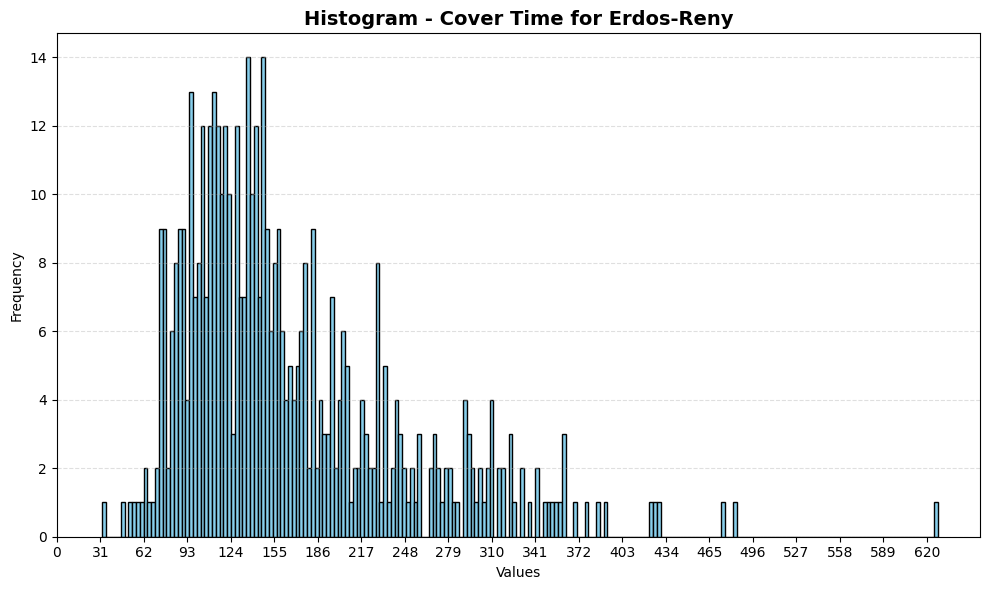

[211, 82, 160, 109, 164, 186, 70, 122, 81, 129, 181, 116, 69, 124, 117, 125, 112, 121, 93, 135, 83, 82, 86, 54, 220, 66, 71, 110, 113, 74, 59, 190, 297, 91, 96, 257, 53, 94, 170, 108, 141, 77, 137, 166, 194, 132, 48, 102, 67, 83, 119, 107, 61, 57, 56, 90, 45, 37, 90, 242, 46, 61, 70, 182, 108, 94, 89, 122, 143, 57, 56, 177, 216, 63, 66, 108, 71, 164, 87, 229, 135, 162, 48, 154, 85, 63, 108, 108, 95, 155, 88, 189, 171, 170, 72, 103, 117, 107, 213, 89, 130, 144, 181, 126, 57, 124, 84, 51, 128, 88, 88, 36, 108, 97, 147, 75, 108, 122, 187, 82, 83, 63, 49, 221, 131, 91, 265, 121, 169, 61, 85, 83, 79, 246, 123, 111, 129, 121, 106, 76, 72, 200, 124, 117, 41, 95, 79, 150, 83, 118, 83, 207, 92, 267, 96, 79, 245, 54, 73, 239, 118, 58, 59, 71, 242, 157, 106, 187, 142, 196, 77, 65, 174, 194, 144, 127, 46, 45, 173, 132, 116, 87, 123, 88, 93, 120, 60, 122, 160, 57, 63, 110, 109, 106, 107, 149, 122, 83, 180, 116, 138, 70, 118, 158, 62, 123, 100, 75, 66, 136, 135, 94, 90, 63, 48, 76, 52, 93, 203, 104,

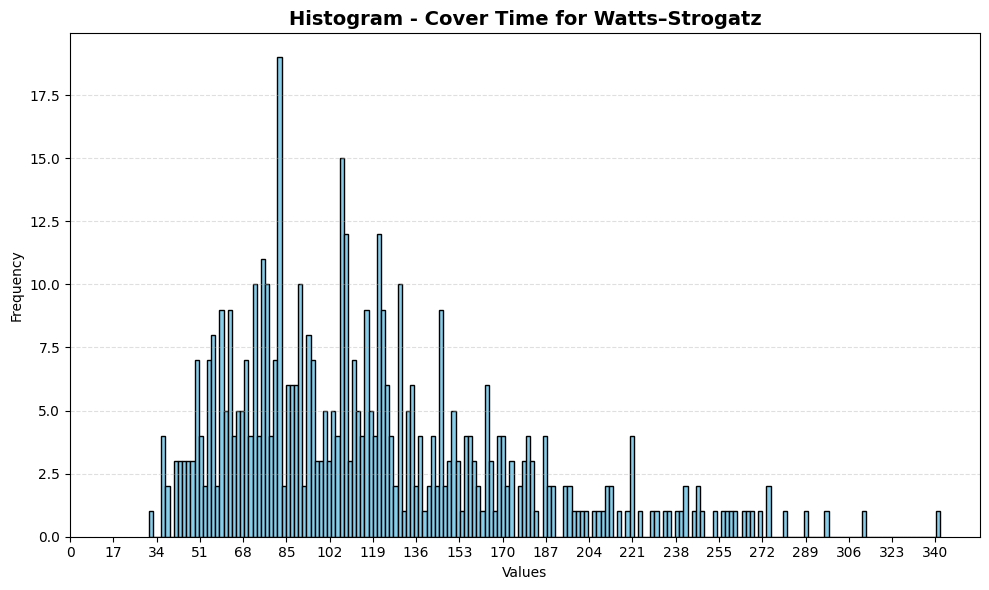

In [76]:
from src.smallworld.simulation import cover_time, plot_cover_time

# ====== Cover Time ======
n_sims = 500
labels = [MAPPING_NAMES[name] for name in graphs.keys()]
for name, graph in graphs.items():
    steps_by_sim, _ = cover_time(G=graph, n_simulations=n_sims)
    print(steps_by_sim)
    plot_cover_time(steps_by_sim, MAPPING_NAMES[name])
